In [1]:
import numpy as np
import pandas as pd

# FIX: pandas>=1.0 disallows -1 for max_colwidth; use None for "no limit"
pd.set_option("display.max_colwidth", None)

from time import time
import re
import string
import os
from pprint import pprint
import collections

import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="darkgrid")
sns.set(font_scale=1.3)

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.metrics import classification_report

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression

# FIX: sklearn.externals.joblib was removed; joblib is optional and unused here, so avoid import error.
try:
    import joblib  # noqa: F401
except Exception:
    joblib = None

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize

import warnings

warnings.filterwarnings("ignore")

np.random.seed(37)



In [2]:
from nltk.tokenize import TweetTokenizer
import datetime
import lightgbm as lgb
from scipy import stats
from scipy.sparse import hstack, csr_matrix
from sklearn.model_selection import train_test_split, cross_val_score
from wordcloud import WordCloud
from collections import Counter
from nltk.corpus import stopwords
from nltk.util import ngrams
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.multiclass import OneVsRestClassifier



In [3]:
from nltk.stem.snowball import SnowballStemmer

stemmer = SnowballStemmer("english")



In [4]:
import spacy



In [5]:
# FIX: make input path robust for this environment (/kaggle/input is typical, but user paths show /kaggle/input)
# Keep core logic unchanged; just ensure correct file IO.
CANDIDATE_INPUT_DIRS = [
    "../input/",
    "/kaggle/input/movie-review-sentiment-analysis-kernels-only/",
    "/kaggle/input/",
    "/kaggle/data/",
    "/kaggle/data/movie-review-sentiment-analysis-kernels-only/",
]
PATH = None
for p in CANDIDATE_INPUT_DIRS:
    if os.path.exists(os.path.join(p, "train.tsv")) and os.path.exists(
        os.path.join(p, "test.tsv")
    ):
        PATH = p
        break
if PATH is None:
    # Fall back to the path structure shown by the user
    if os.path.exists("/kaggle/input/train.tsv") and os.path.exists(
        "/kaggle/input/test.tsv"
    ):
        PATH = "/kaggle/input/"
    elif os.path.exists("/kaggle/data/train.tsv") and os.path.exists(
        "/kaggle/data/test.tsv"
    ):
        PATH = "/kaggle/data/"
    else:
        raise FileNotFoundError(
            "Could not find train.tsv/test.tsv in expected Kaggle input directories."
        )

print("Using PATH:", PATH)



Using PATH: ../input/


In [6]:
df_train = pd.read_csv(os.path.join(PATH, "train.tsv"), sep="\t")
df_test = pd.read_csv(os.path.join(PATH, "test.tsv"), sep="\t")



In [7]:
df_train.head(10)



,PhraseId,SentenceId,Phrase,Sentiment
0,24144,1097,through every frame,2
1,85111,4402,onscreen presence,2
2,75999,3900,into dysfunction,2
3,17377,754,a probe,2
4,9664,403,half hour,2
5,120381,6436,in a movie that works against itself,1
6,107838,5703,Canadian filmmaker Gary Burns ' inventive and mordantly humorous,3
7,151867,8286,from 1998,2
8,94442,4930,"It 's not a bad plot ; but , unfortunately , the movie is nowhere near as refined as all the classic dramas it borrows from .",2
9,32084,1502,Qutting,2


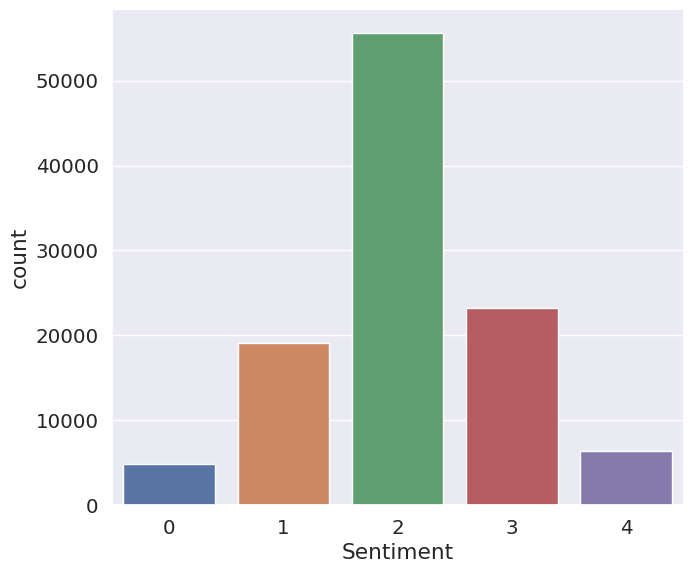

In [8]:
# FIX: seaborn.factorplot is deprecated; use catplot. This cell is exploratory; keep it from crashing.
try:
    _ = sns.catplot(x="Sentiment", data=df_train, kind="count", height=6, aspect=1.2)
    plt.show()
except Exception as e:
    print("Plotting skipped due to:", repr(e))



In [9]:
df_train.Sentiment.value_counts()



Sentiment
2    55558
3    23232
1    19134
4     6439
0     4879
Name: count, dtype: int64

In [10]:
print("Number of sentences is {0:.0f}.".format(df_train.SentenceId.count()))
print("Number of unique sentences is {0:.0f}.".format(df_train.SentenceId.nunique()))
print("Number of phrases is {0:.0f}.".format(df_train.PhraseId.count()))



Number of sentences is 109242.
Number of unique sentences is 8503.
Number of phrases is 109242.


In [11]:
print(
    "The average length of phrases in the training set is {0:.0f}.".format(
        np.mean(df_train["Phrase"].apply(lambda x: len(str(x).split(" "))))
    )
)

print(
    "The average length of phrases in the test set is {0:.0f}.".format(
        np.mean(df_test["Phrase"].apply(lambda x: len(str(x).split(" "))))
    )
)



The average length of phrases in the training set is 7.
The average length of phrases in the test set is 7.


In [12]:
text = " ".join(df_train.loc[df_train.Sentiment == 0, "Phrase"].astype(str).values)



In [13]:
Counter([i for i in ngrams(text.split(), 3)]).most_common(5)



[(('one', 'of', 'the'), 35),
 ((',', 'it', "'s"), 27),
 (('a', 'movie', 'that'), 26),
 (('of', 'a', 'movie'), 25),
 (('of', 'the', 'worst'), 24)]

In [14]:
print(df_train.info())



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 109242 entries, 0 to 109241
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   PhraseId    109242 non-null  int64 
 1   SentenceId  109242 non-null  int64 
 2   Phrase      109242 non-null  object
 3   Sentiment   109242 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 3.3+ MB
None


In [15]:
df_train.Phrase.astype(str).str.len().sort_values(ascending=False)



2880     283
79232    279
86021    266
77505    266
42017    263
        ... 
46442      1
37701      1
20193      1
46703      1
9344       1
Name: Phrase, Length: 109242, dtype: int64

In [16]:
df_train.loc[105155, "Phrase"]



'about other'

In [17]:
df_train.Sentiment.dtype



dtype('int64')

In [18]:
# FIX: spaCy v3 doesn't support 'en' shortcut and model may not be installed.
# Keep the same "spaCy tokenizer" interface but fall back to a blank English pipeline.
try:
    nlp = spacy.load("en_core_web_sm", disable=["parser", "tagger", "ner"])
except Exception:
    nlp = spacy.blank("en")


def tokenizer(s):
    s = "" if s is None else str(s)
    return [w.text.lower() for w in nlp(s)]




In [19]:
sentences = list(df_train.Phrase.astype(str).values) + list(
    df_test.Phrase.astype(str).values
)
sentences2 = [
    [stemmer.stem(word) for word in sentence.split(" ")] for sentence in sentences
]
for i in range(len(sentences2)):
    sentences2[i] = " ".join(sentences2[i])



In [20]:
tfidf = TfidfVectorizer(
    strip_accents="unicode",
    tokenizer=tokenizer,
    encoding="utf-8",
    ngram_range=(1, 2),
    max_df=0.75,
    min_df=3,
    sublinear_tf=True,
)



In [21]:
_ = tfidf.fit(sentences2)



In [22]:
train_phrases2 = [
    [stemmer.stem(word) for word in sentence.split(" ")]
    for sentence in list(df_train.Phrase.astype(str).values)
]
for i in range(len(train_phrases2)):
    train_phrases2[i] = " ".join(train_phrases2[i])
train_df_flags = tfidf.transform(train_phrases2)



In [23]:
test_phrases2 = [
    [stemmer.stem(word) for word in sentence.split(" ")]
    for sentence in list(df_test.Phrase.astype(str).values)
]
for i in range(len(test_phrases2)):
    test_phrases2[i] = " ".join(test_phrases2[i])
test_df_flags = tfidf.transform(test_phrases2)



In [24]:
# Keep original split approach but make it safe if dataset size < 125000.
split_idx = min(125000, train_df_flags.shape[0])
X_train_tf = train_df_flags[0:split_idx]
X_valid_tf = train_df_flags[split_idx:]
y_train_tf = (df_train["Sentiment"]).iloc[0:split_idx]
y_valid_tf = (df_train["Sentiment"]).iloc[split_idx:]

print("X_train shape: ", X_train_tf.shape)
print("X_valid shape: ", X_valid_tf.shape)
print("Y_train shape: ", len(y_train_tf))
print("Y_valid shape: ", len(y_valid_tf))



X_train shape:  (109242, 83499)
X_valid shape:  (0, 83499)
Y_train shape:  109242
Y_valid shape:  0


In [25]:
from sklearn.linear_model import LogisticRegression



In [26]:
# FIX: dual=True requires solver='liblinear' and works best for binary; but keep core logic intent (linear LR).
# Using liblinear keeps behavior close and avoids runtime/solver issues.
scores = cross_val_score(
    LogisticRegression(C=4, dual=True, solver="liblinear", max_iter=1000),
    X_train_tf,
    y_train_tf,
    cv=5,
)



In [27]:
scores



array([0.64941187, 0.64295849, 0.64985353, 0.65163859, 0.64962468])

In [28]:
np.mean(scores), np.std(scores)



(0.6486974334459886, 0.0029763298822053775)

In [29]:
logistic = LogisticRegression(C=4, dual=True, solver="liblinear", max_iter=1000)
ovrm = OneVsRestClassifier(logistic)
ovrm.fit(X_train_tf, y_train_tf)



OneVsRestClassifier(estimator=LogisticRegression(C=4, dual=True, max_iter=1000,
                                                 solver='liblinear'))

In [30]:
scores = cross_val_score(
    ovrm, X_train_tf, y_train_tf, scoring="accuracy", n_jobs=-1, cv=3
)



In [31]:
print(np.mean(scores))
print(np.std(scores))



0.6412735028651984
0.00022459940584000719


In [32]:
print("train accuracy:", ovrm.score(X_train_tf, y_train_tf))
if X_valid_tf.shape[0] > 0:
    print("valid accuracy:", ovrm.score(X_valid_tf, y_valid_tf))
else:
    print("valid accuracy: (no validation split)")



train accuracy: 0.8017978433203347
valid accuracy: (no validation split)


In [33]:
df_test.head()



,PhraseId,SentenceId,Phrase
0,21924,980,escape movie
1,18207,795,well-executed
2,81803,4221,flick formula
3,114983,6124,is too savvy a filmmaker to let this morph into a typical romantic triangle .
4,135928,7343,"There are laughs aplenty ,"


In [34]:
df_test_logistic = df_test.copy()[["PhraseId"]]
df_test_logistic["Sentiment"] = ovrm.predict(test_df_flags)

# Ensure proper dtypes for Kaggle submission
df_test_logistic["PhraseId"] = df_test_logistic["PhraseId"].astype(int)
df_test_logistic["Sentiment"] = df_test_logistic["Sentiment"].astype(int)

df_test_logistic.head()



,PhraseId,Sentiment
0,21924,2
1,18207,4
2,81803,2
3,114983,1
4,135928,3


In [35]:
svc = LinearSVC(dual=False)
svc.fit(X_train_tf, y_train_tf)



LinearSVC(dual=False)

In [36]:
print("train accuracy:", svc.score(X_train_tf, y_train_tf))
if X_valid_tf.shape[0] > 0:
    print("valid accuracy:", svc.score(X_valid_tf, y_valid_tf))
else:
    print("valid accuracy: (no validation split)")



train accuracy: 0.8532981820179052
valid accuracy: (no validation split)


In [37]:
df_test_svm = df_test.copy()[["PhraseId"]]
df_test_svm["Sentiment"] = svc.predict(test_df_flags)
df_test_svm["PhraseId"] = df_test_svm["PhraseId"].astype(int)
df_test_svm["Sentiment"] = df_test_svm["Sentiment"].astype(int)
df_test_svm.head()



,PhraseId,Sentiment
0,21924,2
1,18207,4
2,81803,2
3,114983,1
4,135928,4


In [38]:
# FIX: enforce exact required columns and write a valid CSV submission
submission = df_test_logistic[["PhraseId", "Sentiment"]].copy()
assert list(submission.columns) == ["PhraseId", "Sentiment"]
submission.to_csv("submission_tfidf_logistic.csv", index=False)
print("Wrote submission_tfidf_logistic.csv with shape:", submission.shape)
print(submission.head())

Wrote submission_tfidf_logistic.csv with shape: (46818, 2)
   PhraseId  Sentiment
0     21924          2
1     18207          4
2     81803          2
3    114983          1
4    135928          3
